# Model 2 — Similar Car Finder & Price Range Recommendation (kNN)

**Project Question:** Given my car's specifications, in which price range should I sell my car according to the cars in the dataset that are most similar to mine?

## Objective
This notebook uses **k-Nearest Neighbors (kNN)** with `NearestNeighbors` to find the most similar cars in the dataset and recommend a fair selling price range based on the real prices of those similar cars.

## Method Summary
- Load the scaled dataset for distance calculation.
- Load the unscaled dataset to display real car values and prices.
- Select meaningful similarity features.
- Fit a kNN model using Euclidean distance.
- Show the selected query/target car at the top of the neighbor table.
- Find similar cars and calculate a recommended price range using **Median ± IQR**.
- Visualize only `lower_bound`, `upper_bound`, and `query_price` with a clean range plot.
- Evaluate different `k` values using 3 query cars and the deviation formula:

\[
Dev = (upper\_bound - query\_price)^2 + (lower\_bound - query\_price)^2
\]

The smaller the deviation score, the more reliable the selected `k` value is considered.


## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

scaled_url = 'https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/processed_dataset.csv'
unscaled_url = 'https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv'

df_scaled = pd.read_csv(scaled_url)
df_unscaled = pd.read_csv(unscaled_url)

# Attach real price values to the scaled dataframe for price lookups.
if 'Fiyat' in df_unscaled.columns:
    df_scaled['Fiyat'] = df_unscaled['Fiyat']
elif 'Fiyat_original' in df_scaled.columns:
    df_scaled['Fiyat'] = df_scaled['Fiyat_original']
else:
    raise ValueError('Price column was not found. Please check the dataset columns.')

print(f'Scaled dataset shape: {df_scaled.shape}')
print(f'Unscaled dataset shape: {df_unscaled.shape}')
df_scaled.head()

Scaled dataset shape: (2589, 88)
Unscaled dataset shape: (2589, 87)


,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,Yakıt Deposu,...,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat,Fiyat_original,Fiyat
0,1.388641,-1.289586,0.420748,0.463442,0.364293,1.359964,-2.803043,-0.172722,0.549434,-0.653204,...,-0.102909,-0.293614,-0.469975,-0.809089,-0.747773,-0.159292,-0.442605,1.384169,2425000,2425000
1,1.388641,-1.178174,0.599267,0.994204,0.267896,1.367419,0.273294,-0.172722,0.828322,-0.384329,...,0.036678,0.975345,0.023313,-0.286926,-0.090398,0.014411,1.296250,1.820704,2900000,2900000
2,-0.529613,1.596267,0.040836,1.345487,-0.900493,-0.458785,0.273294,-0.172722,-0.735812,0.009815,...,-0.170805,-0.474894,-0.469975,-0.597253,-0.504301,-0.159292,1.296250,-0.436532,1150000,1150000
3,-0.721438,0.827446,-0.141989,0.961936,-0.900493,-0.458785,0.273294,-0.172722,-0.735812,0.009815,...,-0.170805,-0.474894,-0.469975,-0.184536,-0.036834,-0.159292,-0.442605,-0.252650,1240000,1240000
4,-1.296915,2.041960,-0.406661,0.203775,-0.594877,-1.269542,0.273294,-0.172722,-0.146060,0.855780,...,-0.463131,-1.079160,-0.117627,-0.508686,-0.299784,-0.306538,-1.312033,-1.683144,690000,690000


## 2. Feature Selection

In [2]:
recommended_features = [
    'Yıl', 'Kilometre', 'Motor Hacmi', 'Motor Gücü', 'Vites Tipi',
    'Kasa Tipi_SUV', 'Kasa Tipi_Crossover',
    'Yakıt Tipi_Dizel', 'Yakıt Tipi_Hibrit',
    'paint_damage_score', 'total_changed_parts',
    'Ağırlık', 'Boş Ağırlığı', 'Maksimum Hız'
]

features = [f for f in recommended_features if f in df_scaled.columns]
X = df_scaled[features].fillna(0)

print(f'Feature matrix shape: {X.shape}')
print('Features used:')
for f in features:
    print('-', f)

Feature matrix shape: (2589, 14)
Features used:
- Yıl
- Kilometre
- Motor Hacmi
- Motor Gücü
- Vites Tipi
- Kasa Tipi_SUV
- Kasa Tipi_Crossover
- Yakıt Tipi_Dizel
- Yakıt Tipi_Hibrit
- paint_damage_score
- total_changed_parts
- Ağırlık
- Boş Ağırlığı
- Maksimum Hız


## 3. Helper Function — Find Similar Cars and Recommend Price Range

This function:
- selects a query/target car,
- fits a `NearestNeighbors` model,
- finds the most similar cars,
- displays the query car at the top of the table,
- calculates the recommended price range using **Median ± IQR**.


In [3]:
def find_similar_cars(query_idx=42, k=10, show_table=True, verbose=True):
    """Find k most similar cars and recommend a fair selling range."""
    if query_idx < 0 or query_idx >= len(df_scaled):
        raise ValueError(f'query_idx must be between 0 and {len(df_scaled)-1}')

    knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
    knn.fit(X)

    query_car = X.iloc[[query_idx]]
    distances, indices = knn.kneighbors(query_car)

    # Exclude the query car itself from neighbors.
    neighbor_indices = indices[0][1:]
    neighbor_distances = distances[0][1:]

    neighbor_prices = df_scaled.iloc[neighbor_indices]['Fiyat'].values
    query_price = df_scaled.iloc[query_idx]['Fiyat']

    median_price = np.median(neighbor_prices)
    q1 = np.percentile(neighbor_prices, 25)
    q3 = np.percentile(neighbor_prices, 75)
    iqr = q3 - q1
    lower_bound = median_price - iqr
    upper_bound = median_price + iqr

    display_cols = [
        'Yıl', 'Kilometre', 'Motor Hacmi', 'Motor Gücü', 'Vites Tipi',
        'Kasa Tipi_SUV', 'Kasa Tipi_Crossover',
        'Yakıt Tipi_Dizel', 'Yakıt Tipi_Hibrit',
        'paint_damage_score', 'total_changed_parts', 'Fiyat'
    ]
    display_cols_available = [c for c in display_cols if c in df_unscaled.columns]

    # Query/target car row at the top.
    query_row = df_unscaled.iloc[[query_idx]][display_cols_available].copy()
    if 'Fiyat' not in query_row.columns:
        query_row['Fiyat'] = query_price
    query_row['kNN Distance'] = 0.0
    query_row.insert(0, 'Type', 'QUERY / TARGET')

    # Similar cars below it.
    neighbors_df = df_unscaled.iloc[neighbor_indices][display_cols_available].copy()
    if 'Fiyat' not in neighbors_df.columns:
        neighbors_df['Fiyat'] = neighbor_prices
    neighbors_df['kNN Distance'] = neighbor_distances
    neighbors_df.insert(0, 'Type', 'SIMILAR CAR')

    result_table = pd.concat([query_row, neighbors_df], axis=0)
    result_table.index = ['Target'] + [f'Neighbor {i}' for i in range(1, k + 1)]

    if query_price < lower_bound:
        interpretation = 'The query car appears cheaper than the recommended range.'
    elif query_price > upper_bound:
        interpretation = 'The query car appears more expensive than the recommended range.'
    else:
        interpretation = 'The query car price is inside the recommended fair price range.'

    if verbose:
        print('=' * 80)
        print(f'Query/Target car index: {query_idx}')
        print(f'k value: {k}')
        print(f'Query car actual price: {query_price:,.0f} TL')
        print('-' * 80)
        print(f'Recommended fair price range: {lower_bound:,.0f} TL — {upper_bound:,.0f} TL')
        print(f'Median of similar cars: {median_price:,.0f} TL')
        print(f'Q1: {q1:,.0f} TL | Q3: {q3:,.0f} TL | IQR: {iqr:,.0f} TL')
        print('Interpretation:', interpretation)
        print('=' * 80)

    if show_table:
        display(result_table.style.format({
            'Fiyat': '{:,.0f} TL',
            'kNN Distance': '{:.4f}'
        }))

    return {
        'query_idx': query_idx,
        'k': k,
        'query_price': query_price,
        'neighbor_indices': neighbor_indices,
        'neighbor_distances': neighbor_distances,
        'neighbor_prices': neighbor_prices,
        'median_price': median_price,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'result_table': result_table,
        'interpretation': interpretation
    }

## 4. Main Demo — Query Car with k = 10

In [4]:
main_result = find_similar_cars(query_idx=42, k=10, show_table=True, verbose=True)

Query/Target car index: 42
k value: 10
Query car actual price: 725,000 TL
--------------------------------------------------------------------------------
Recommended fair price range: 517,750 TL — 855,250 TL
Median of similar cars: 686,500 TL
Q1: 608,750 TL | Q3: 777,500 TL | IQR: 168,750 TL
Interpretation: The query car price is inside the recommended fair price range.


,Type,Yıl,Kilometre,Motor Hacmi,Motor Gücü,Vites Tipi,Kasa Tipi_SUV,Kasa Tipi_Crossover,Yakıt Tipi_Dizel,Yakıt Tipi_Hibrit,paint_damage_score,total_changed_parts,Fiyat,kNN Distance
Target,QUERY / TARGET,2016,465000,2250.500000,5.099866,0,1.000000,0.000000,1.000000,0.000000,2.079442,0.000000,"725,000 TL",0.0000
Neighbor 1,SIMILAR CAR,2011,370000,2250.500000,5.099866,0,1.000000,0.000000,1.000000,0.000000,1.945910,0.000000,"635,000 TL",2.2744
Neighbor 2,SIMILAR CAR,2008,450000,2250.500000,4.934474,0,1.000000,0.000000,1.000000,0.000000,1.609438,0.000000,"515,000 TL",2.5926
Neighbor 3,SIMILAR CAR,2007,360000,2250.500000,5.099866,0,1.000000,0.000000,1.000000,0.000000,2.484907,0.000000,"530,000 TL",2.6409
Neighbor 4,SIMILAR CAR,2016,303000,2250.500000,5.099866,0,1.000000,0.000000,1.000000,0.000000,1.386294,0.693147,"795,000 TL",2.9115
Neighbor 5,SIMILAR CAR,2011,298000,2250.500000,4.934474,0,1.000000,0.000000,1.000000,0.000000,1.386294,0.000000,"678,000 TL",3.0288
Neighbor 6,SIMILAR CAR,2020,229489,2250.500000,5.099866,0,1.000000,0.000000,1.000000,0.000000,0.693147,0.000000,"1,450,000 TL",3.3677
Neighbor 7,SIMILAR CAR,2011,301000,2250.500000,4.934474,0,1.000000,0.000000,1.000000,0.000000,2.079442,0.000000,"600,000 TL",3.4254
Neighbor 8,SIMILAR CAR,2020,185000,2250.500000,5.099866,0,1.000000,0.000000,1.000000,0.000000,1.098612,0.000000,"1,380,000 TL",3.5011
Neighbor 9,SIMILAR CAR,2013,376000,2250.500000,5.099866,0,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,"695,000 TL",3.5825


## 5. Clean Visualization — Recommended Range vs Query Price

This plot is intentionally not a boxplot and not a line chart. It only shows:
- the recommended price interval: `lower_bound → upper_bound`
- the actual `query_price`

This directly answers the question: **Is the query car price inside or outside the recommended range?**


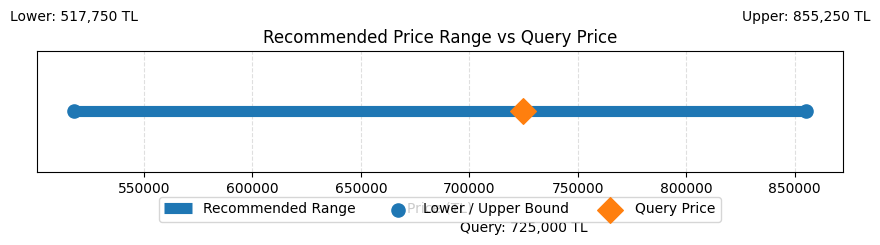

In [5]:
def plot_single_price_range(result):
    lower = result['lower_bound']
    upper = result['upper_bound']
    query_price = result['query_price']

    fig, ax = plt.subplots(figsize=(9, 3.5))

    # Recommended interval.
    ax.hlines(y=1, xmin=lower, xmax=upper, linewidth=8, label='Recommended Range')

    # Range borders.
    ax.scatter([lower, upper], [1, 1], s=90, label='Lower / Upper Bound')

    # Query price.
    ax.scatter(query_price, 1, s=170, marker='D', label='Query Price', zorder=5)

    # Text labels.
    y_text = 1.08
    ax.text(lower, y_text, f'Lower: {lower:,.0f} TL', ha='center', va='bottom')
    ax.text(upper, y_text, f'Upper: {upper:,.0f} TL', ha='center', va='bottom')
    ax.text(query_price, 0.90, f'Query: {query_price:,.0f} TL', ha='center', va='top')

    ax.set_title('Recommended Price Range vs Query Price')
    ax.set_xlabel('Price (TL)')
    ax.set_yticks([])
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.tight_layout()
    plt.show()

plot_single_price_range(main_result)

### Interpretation of the Main Range Plot

The horizontal interval represents the recommended fair selling range. The diamond marker shows the query car's actual price. If the marker is inside the interval, the query price is consistent with similar cars. If it is outside, the car may be underpriced or overpriced compared with its nearest neighbors.


## 6. Similarity Distance Bar Chart

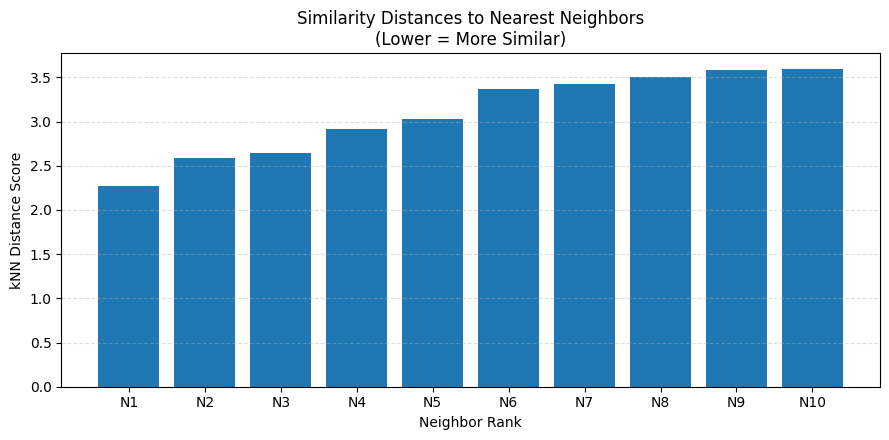

In [6]:
def plot_similarity_distances(result):
    distances = result['neighbor_distances']
    ranks = [f'N{i+1}' for i in range(len(distances))]

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(ranks, distances)
    ax.set_xlabel('Neighbor Rank')
    ax.set_ylabel('kNN Distance Score')
    ax.set_title('Similarity Distances to Nearest Neighbors\n(Lower = More Similar)')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_similarity_distances(main_result)

## 7. k Value Evaluation Using 3 Cars and Deviation Score

For each suggested `k` value, the model tests **3 different query cars**. For each car, it calculates:

\[
Dev = (upper\_bound - query\_price)^2 + (lower\_bound - query\_price)^2
\]

This deviation measures how far the actual query price is from both boundaries of the recommended interval. A smaller deviation means the selected `k` produces a more reliable range around the real query price.


In [7]:
def calculate_range_deviation(result):
    query_price = result['query_price']
    lower = result['lower_bound']
    upper = result['upper_bound']
    dev = (upper - query_price) ** 2 + (lower - query_price) ** 2
    return dev

k_values = [5, 10, 15]
query_indices = [42, 100, 500]

experiment_rows = []

for k in k_values:
    for idx in query_indices:
        result = find_similar_cars(query_idx=idx, k=k, show_table=False, verbose=False)
        dev = calculate_range_deviation(result)
        experiment_rows.append({
            'k': k,
            'Query Index': idx,
            'Query Price': result['query_price'],
            'Lower Bound': result['lower_bound'],
            'Upper Bound': result['upper_bound'],
            'Median Price': result['median_price'],
            'Deviation': dev,
            'Deviation (Trillion TL^2)': dev / 1_000_000_000_000,
            'Interpretation': result['interpretation']
        })

experiment_df = pd.DataFrame(experiment_rows)

experiment_df.style.format({
    'Query Price': '{:,.0f} TL',
    'Lower Bound': '{:,.0f} TL',
    'Upper Bound': '{:,.0f} TL',
    'Median Price': '{:,.0f} TL',
    'Deviation': '{:,.0f}',
    'Deviation (Trillion TL^2)': '{:.3f}'
})

,k,Query Index,Query Price,Lower Bound,Upper Bound,Median Price,Deviation,Deviation (Trillion TL^2),Interpretation
0,5,42,"725,000 TL","487,000 TL","783,000 TL","635,000 TL","60,008,000,000",0.060,The query car price is inside the recommended fair price range.
1,5,100,"1,195,000 TL","1,151,500 TL","1,243,500 TL","1,197,500 TL","4,244,500,000",0.004,The query car price is inside the recommended fair price range.
2,5,500,"850,000 TL","800,000 TL","900,000 TL","850,000 TL","5,000,000,000",0.005,The query car price is inside the recommended fair price range.
3,10,42,"725,000 TL","517,750 TL","855,250 TL","686,500 TL","59,917,625,000",0.060,The query car price is inside the recommended fair price range.
4,10,100,"1,195,000 TL","1,090,750 TL","1,295,750 TL","1,193,250 TL","21,018,625,000",0.021,The query car price is inside the recommended fair price range.
5,10,500,"850,000 TL","787,000 TL","933,000 TL","860,000 TL","10,858,000,000",0.011,The query car price is inside the recommended fair price range.
6,15,42,"725,000 TL","460,000 TL","990,000 TL","725,000 TL","140,450,000,000",0.140,The query car price is inside the recommended fair price range.
7,15,100,"1,195,000 TL","1,042,500 TL","1,352,500 TL","1,197,500 TL","48,062,500,000",0.048,The query car price is inside the recommended fair price range.
8,15,500,"850,000 TL","758,000 TL","982,000 TL","870,000 TL","25,888,000,000",0.026,The query car price is inside the recommended fair price range.


## 8. Compact k Comparison Summary

Instead of writing long explanations for every query car, this table summarizes the average deviation for each `k` value. The best `k` is the one with the lowest average deviation.


In [8]:
k_summary_df = experiment_df.groupby('k').agg(
    Tested_Cars=('Query Index', 'count'),
    Average_Deviation=('Deviation', 'mean'),
    Minimum_Deviation=('Deviation', 'min'),
    Maximum_Deviation=('Deviation', 'max')
).reset_index()

k_summary_df['Average Deviation (Trillion TL^2)'] = k_summary_df['Average_Deviation'] / 1_000_000_000_000
k_summary_df['Minimum Deviation (Trillion TL^2)'] = k_summary_df['Minimum_Deviation'] / 1_000_000_000_000
k_summary_df['Maximum Deviation (Trillion TL^2)'] = k_summary_df['Maximum_Deviation'] / 1_000_000_000_000

best_k = k_summary_df.loc[k_summary_df['Average_Deviation'].idxmin(), 'k']
print(f'Best k according to the lowest average deviation: k = {best_k}')

k_summary_display = k_summary_df[[
    'k', 'Tested_Cars',
    'Average Deviation (Trillion TL^2)',
    'Minimum Deviation (Trillion TL^2)',
    'Maximum Deviation (Trillion TL^2)'
]]

k_summary_display.style.format({
    'Average Deviation (Trillion TL^2)': '{:.3f}',
    'Minimum Deviation (Trillion TL^2)': '{:.3f}',
    'Maximum Deviation (Trillion TL^2)': '{:.3f}'
})

Best k according to the lowest average deviation: k = 5


,k,Tested_Cars,Average Deviation (Trillion TL^2),Minimum Deviation (Trillion TL^2),Maximum Deviation (Trillion TL^2)
0,5,3,0.023,0.004,0.060
1,10,3,0.031,0.011,0.060
2,15,3,0.071,0.026,0.140


## 9. Visualization — k Reliability by Average Deviation

This bar chart compares `k` values using the average deviation score across 3 query cars. The smallest bar indicates the most reliable `k` value according to the chosen deviation formula.


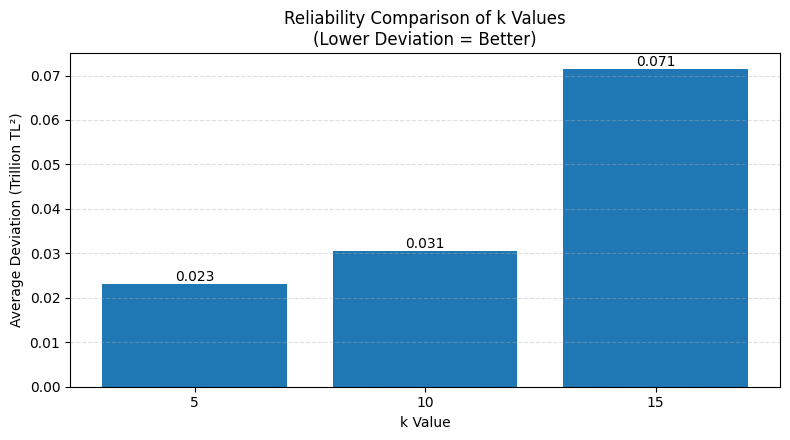

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))

x_labels = k_summary_df['k'].astype(str)
y_values = k_summary_df['Average Deviation (Trillion TL^2)']

ax.bar(x_labels, y_values)
ax.set_xlabel('k Value')
ax.set_ylabel('Average Deviation (Trillion TL²)')
ax.set_title('Reliability Comparison of k Values\n(Lower Deviation = Better)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

for i, value in enumerate(y_values):
    ax.text(i, value, f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 10. Visualization — Price Range Intervals for All Test Cases

This plot shows every test case used in the `k` evaluation. Each horizontal segment is the recommended price interval, and the point is the actual query price.


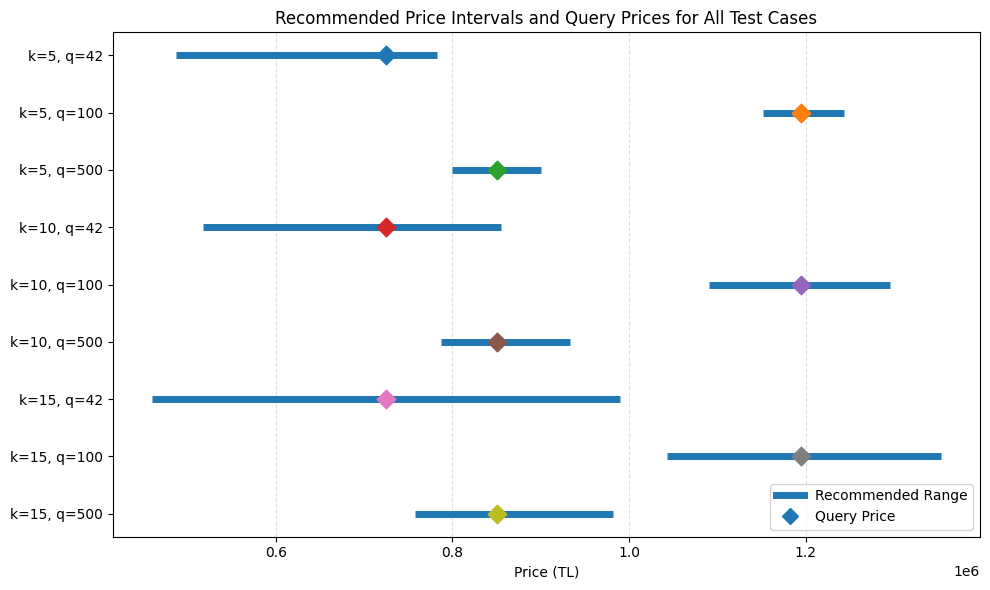

In [10]:
def plot_all_range_intervals(experiment_df):
    plot_df = experiment_df.copy().reset_index(drop=True)
    plot_df['Label'] = plot_df.apply(lambda r: f"k={int(r['k'])}, q={int(r['Query Index'])}", axis=1)

    fig, ax = plt.subplots(figsize=(10, 6))
    y_positions = np.arange(len(plot_df))

    for y, (_, row) in zip(y_positions, plot_df.iterrows()):
        ax.hlines(
            y=y,
            xmin=row['Lower Bound'],
            xmax=row['Upper Bound'],
            linewidth=5
        )
        ax.scatter(
            row['Query Price'],
            y,
            marker='D',
            s=90,
            zorder=5
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(plot_df['Label'])
    ax.set_xlabel('Price (TL)')
    ax.set_title('Recommended Price Intervals and Query Prices for All Test Cases')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.invert_yaxis()

    # Simple legend using invisible handles.
    interval_handle = plt.Line2D([0], [0], linewidth=5, label='Recommended Range')
    query_handle = plt.Line2D([0], [0], marker='D', linestyle='', markersize=8, label='Query Price')
    ax.legend(handles=[interval_handle, query_handle], loc='lower right')

    plt.tight_layout()
    plt.show()

plot_all_range_intervals(experiment_df)

### k Evaluation Interpretation

The deviation score compares how far the query price is from both the lower and upper bounds of the recommended interval. Because every `k` value is tested on 3 different cars, the comparison is more reliable than testing only one example. The `k` value with the smallest average deviation is selected as the best option for this dataset and feature set.


## 11. Final Interpretation

The kNN model provides a practical and explainable recommendation system. Instead of directly predicting a price with a black-box regression model, it finds vehicles that are similar to the query car and uses their real market prices to calculate a fair selling range.

The range-based visualization is more suitable than a boxplot because the main goal is not outlier detection. The goal is to show whether the query price falls inside the recommended price interval.


## 12. Limitations and Improvement Suggestions

Although the model works successfully, there are some limitations:

- Brand and exact model identity may not be fully represented in the selected features.
- Luxury and economy cars may sometimes appear similar if they share year, mileage, and technical values.
- Outlier prices can still affect the median and IQR range.
- The result depends heavily on correct scaling and feature selection.

Possible improvements:

- Add stronger brand/model-related features if available.
- Compare different distance metrics.
- Remove extreme outlier prices before training.
- Test more query cars and report average behavior.


## Conclusion

This project successfully applies a kNN-based similarity search to recommend a fair price range for a car. The model is interpretable because every recommendation is based on actual similar cars from the dataset. The improved deviation-based `k` evaluation also provides a clearer way to compare which `k` value produces more reliable price intervals.
